In [1]:
# retrieve ohlcv data
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

from dotenv import load_dotenv
import os

import datetime as dt

import pandas as pd
import numpy as np
from scipy.stats import entropy

# load environment variables (adjust path if needed)
load_dotenv("../.env")

# initialize alpaca client
API_KEY = os.getenv("APCA_API_KEY_ID")
SECRET_KEY = os.getenv("APCA_API_SECRET_KEY")
client = StockHistoricalDataClient(API_KEY, SECRET_KEY)

# create and send the request
request = StockBarsRequest(
    symbol_or_symbols="TSLA",
    timeframe=TimeFrame.Minute,
    start=dt.datetime.now()-dt.timedelta(days=30),
    end=dt.datetime.now()
)

bars = client.get_stock_bars(request).df

In [2]:
# create 30 minute windows

# If bars has a MultiIndex, reset it so 'timestamp' is a column
if isinstance(bars.index, pd.MultiIndex):
    bars = bars.reset_index()

# Convert the 'timestamp' column to datetime and set it as index
bars['timestamp'] = pd.to_datetime(bars['timestamp'])
bars = bars.set_index('timestamp').sort_index()

# Now create 30-minute windows
window_size = pd.Timedelta(minutes=30)
start_time = bars.index[0]
end_time = bars.index[-1]

windows = []
current_start = start_time

while current_start < end_time:
    current_end = current_start + window_size
    window_data = bars.loc[current_start:current_end]
    if not window_data.empty:
        windows.append(window_data)
    current_start = current_end

print(f"Total windows created: {len(windows)}")

Total windows created: 693


In [4]:
# calculate entropy

def calculate_entropy(window_df):
    # Example: use close price returns in the window
    returns = window_df['close'].pct_change().dropna()
    
    # Discretize returns into bins (e.g. 10 bins)
    bins = np.histogram_bin_edges(returns, bins=10)
    digitized = np.digitize(returns, bins)
    
    # Calculate probabilities of each bin
    counts = np.bincount(digitized)
    probs = counts / counts.sum()
    
    # Remove zero probabilities (entropy requires strictly positive probs)
    probs = probs[probs > 0]
    
    # Shannon entropy
    return entropy(probs, base=2)

# Calculate entropy for all windows and store results
entropy_values = []
window_timestamps = []

for window_df in windows:
    ent = calculate_entropy(window_df)
    entropy_values.append(ent)
    window_timestamps.append(window_df.index[0])

# Put results into a DataFrame for analysis/plotting
entropy_df = pd.DataFrame({
    'start_time': window_timestamps,
    'entropy': entropy_values
}).set_index('start_time')

In [7]:
# determine signals

# Set thresholds for low/high entropy (you can tune these)
low_threshold = entropy_df['entropy'].quantile(0.2)
high_threshold = entropy_df['entropy'].quantile(0.8)

# Initialize signal column
entropy_df['signal'] = 0

# Assign signals safely using .loc
for i in range(1, len(entropy_df)):
    idx = entropy_df.index[i]
    if entropy_df['entropy'].iloc[i] < low_threshold:
        entropy_df.loc[idx, 'signal'] = 1    # Buy signal
    elif entropy_df['entropy'].iloc[i] > high_threshold:
        entropy_df.loc[idx, 'signal'] = -1   # Sell signal
    else:
        entropy_df.loc[idx, 'signal'] = 0    # Hold

Final portfolio value: $11422.49
Total return: 14.22%


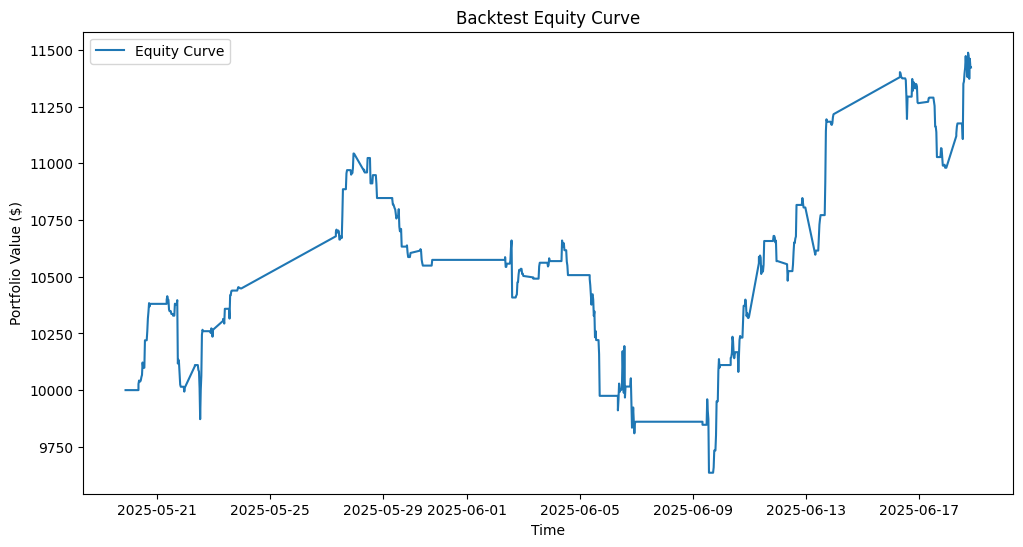

In [10]:
# backtest

initial_cash = 10000
cash = initial_cash
shares = 0
portfolio_values = []

# Assuming entropy_df indexed by window-end timestamps
# and 'bars' contains minute-level price data with a 'close' column.

# Resample or pick the close price at each entropy window timestamp:
close_prices = bars['close'].reindex(entropy_df.index, method='nearest')

# Add the close price to entropy_df
entropy_df = entropy_df.copy()
entropy_df['close'] = close_prices

# Now you can run your backtest code that uses entropy_df['close']

# Assume you have price info in entropy_df['close'] aligned with signals
for idx, row in entropy_df.iterrows():
    price = row['close']
    signal = row['signal']
    
    if signal == 1 and shares == 0:  # Buy
        shares = cash // price
        cash -= shares * price
        # print(f"BUY {shares} shares at {price} on {idx}")
    elif signal == -1 and shares > 0:  # Sell
        cash += shares * price
        shares = 0
        # print(f"SELL all shares at {price} on {idx}")
    # else hold
    
    total_value = cash + shares * price
    portfolio_values.append((idx, total_value))

# Convert to DataFrame for analysis
portfolio_df = pd.DataFrame(portfolio_values, columns=['timestamp', 'portfolio_value']).set_index('timestamp')

# Show final portfolio value and return %
final_value = portfolio_df['portfolio_value'].iloc[-1]
returns = (final_value - initial_cash) / initial_cash * 100
print(f"Final portfolio value: ${final_value:.2f}")
print(f"Total return: {returns:.2f}%")

# Optional: plot equity curve
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(portfolio_df.index, portfolio_df['portfolio_value'], label='Equity Curve')
plt.title('Backtest Equity Curve')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Time')
plt.legend()
plt.show()